In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys



sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
from spk_lfp_cluster_comp_analysis  import *


In [4]:
feature_shades = {
    'peak_amp_cluster': '#8c564b', 'peak_sharpness_cluster': '#a06d62', 'peak_width_cluster': '#b38479',
    'exp_const_cluster': '#e377c2', 'exp_lambda_cluster': '#c561a8',
    'inflection_amp_cluster': '#d62728', 'inflection_time_cluster': '#e05354',
    'ramp_amp_cluster': '#ff7f0e', 'log_isi_cluster': '#7f7f7f',
    'spk_times_ms_cluster': '#cccccc'
}

#### Compile all the pickles we generated 

In [2]:
df_pop_stats, pop_traces = compile_lfp_stats()


#### Run effect size summary

=== SIGNIFICANT HITS SUMMARY ===


,lfp_feature,spike_feature,sig_windows_count,median_cohens_d
0,Gamma AUC,peak_amp_cluster,3,0.285823
1,Aperiodic Exponent,peak_amp_cluster,3,0.253402
2,Theta AUC,log_isi_cluster,7,0.246625
3,Gamma AUC,exp_lambda_cluster,2,0.232224
4,Theta AUC,peak_amp_cluster,3,0.226072
5,Theta AUC,exp_lambda_cluster,5,0.219462
6,Theta AUC,peak_width_cluster,10,0.184644
7,Aperiodic Offset,peak_amp_cluster,2,0.181401
8,Gamma AUC,peak_width_cluster,4,0.170409
9,Aperiodic Offset,log_isi_cluster,8,0.166402


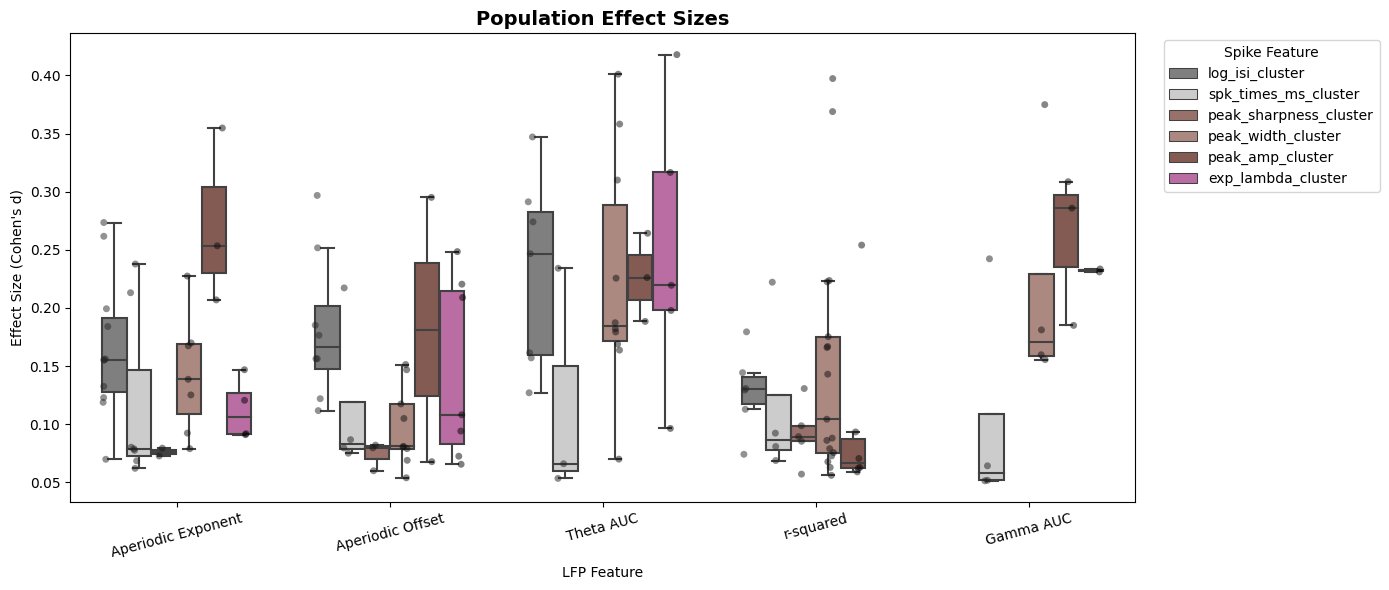

In [6]:
plot_population_effect_sizes(df_pop_stats, feature_shades)


#### Run the Window Timing Distribution

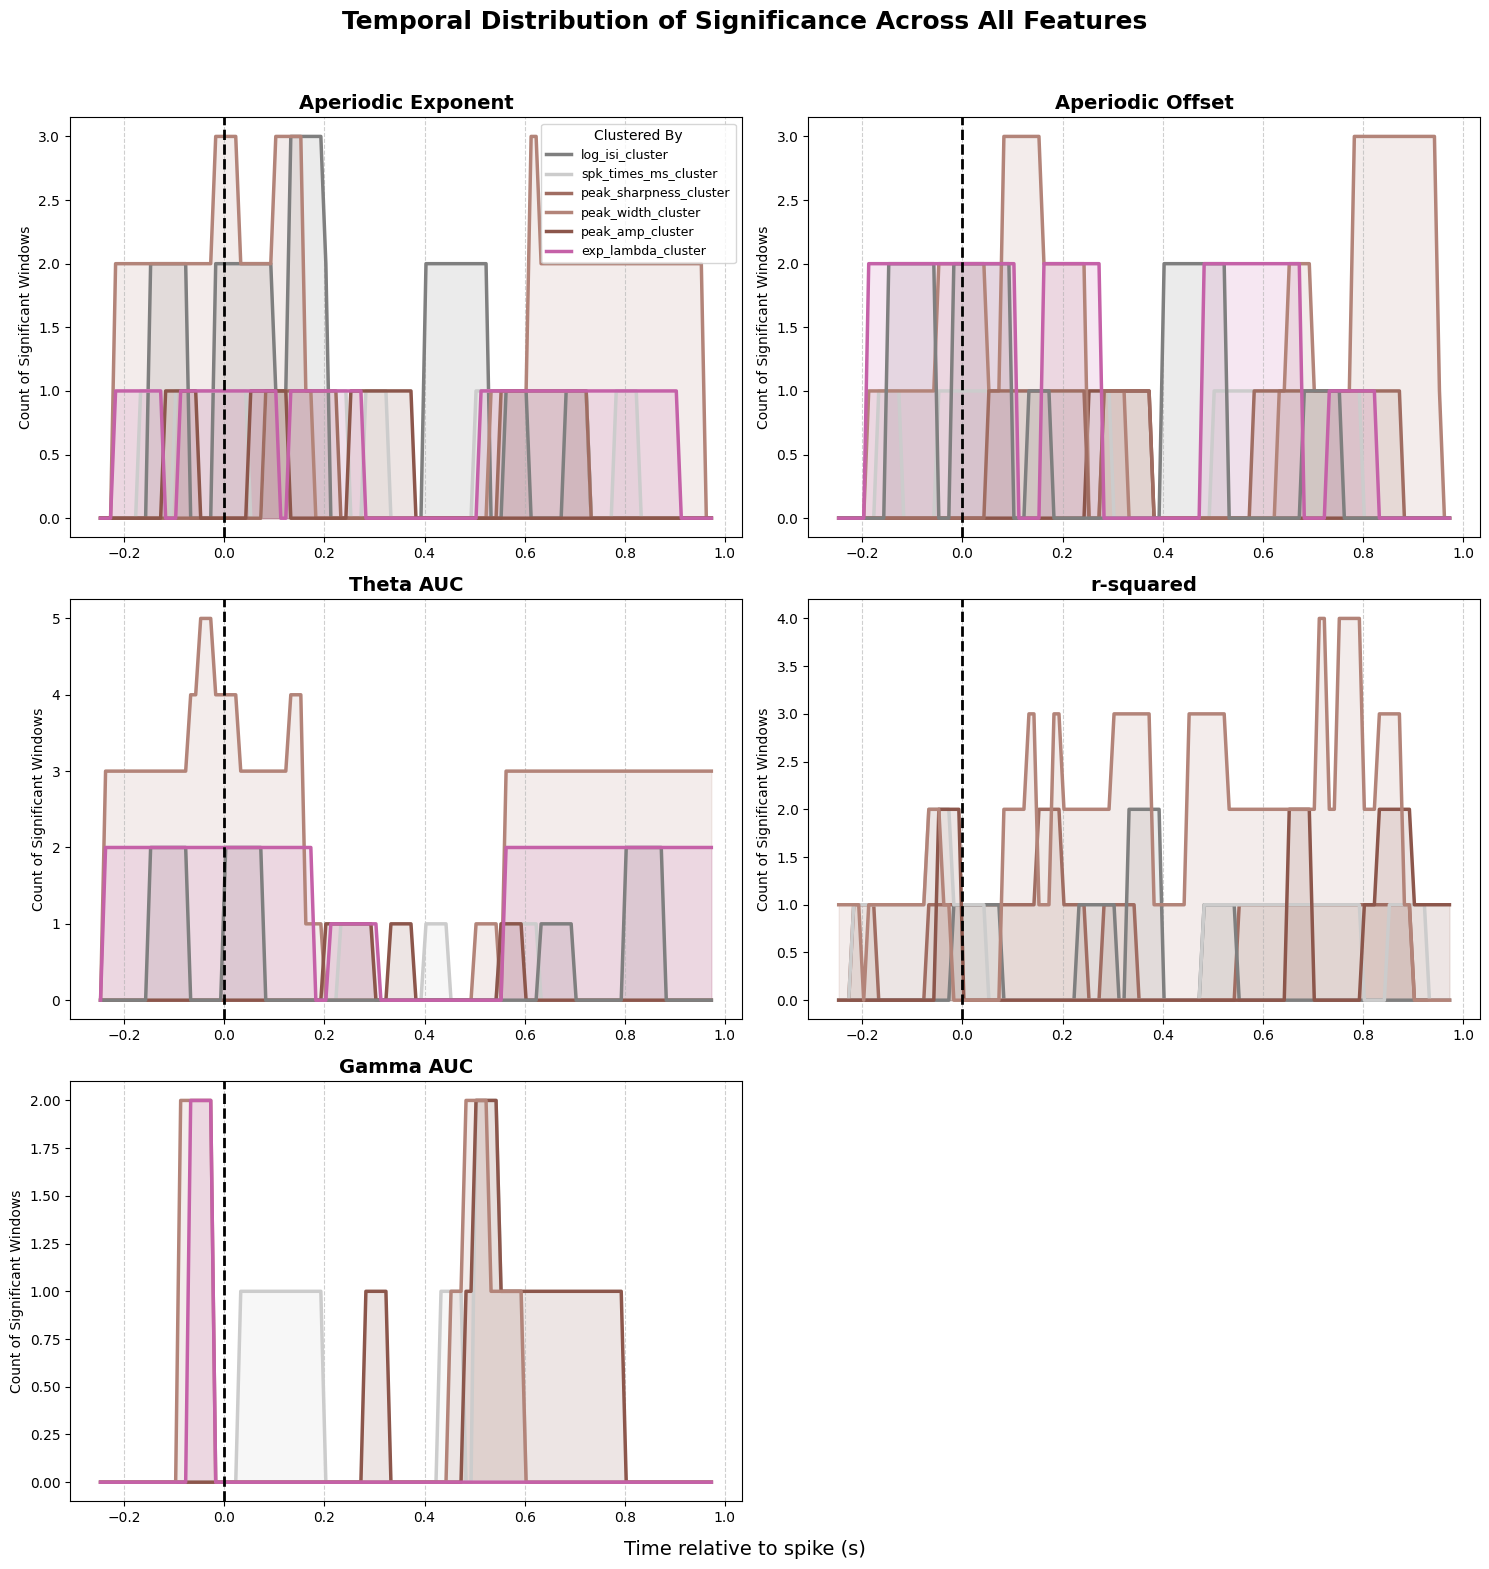

In [7]:
plot_temporal_significance_density(df_pop_stats, feature_shades)


In [17]:
# ==========================================
# 4. PLOT ALL GRAND AVERAGE TRACES (GRID)
# ==========================================

def plot_all_grand_average_traces(master_traces):
    """
    Generates a master grid of population Grand Average traces for EVERY 
    LFP feature and spike feature combination.
    Uses interpolation to rescue cells with slightly mismatched array lengths.
    """
    unique_lfp_features = sorted(list(set(t["lfp_feature"] for t in master_traces)))
    unique_spike_features = sorted(list(set(t["spike_feature"] for t in master_traces)))
    
    if not unique_lfp_features:
        print("No traces found in the dataset!")
        return
        
    # Define a MASTER time grid from the very first valid trace
    master_Tgrid = None
    for t in master_traces:
        if "trace_data" in t and "Tgrid" in t["trace_data"]:
            master_Tgrid = t["trace_data"]["Tgrid"]
            break
            
    if master_Tgrid is None:
        print("Could not find 'Tgrid' in any trace data!")
        return

    # Loop through each LFP feature and create a new figure
    for lfp_feat in unique_lfp_features:
        n_spk = len(unique_spike_features)
        cols = 3
        rows = math.ceil(n_spk / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
        if n_spk == 1: axes = [axes]
        else: axes = axes.flatten()
        
        for idx, spk_feat in enumerate(unique_spike_features):
            ax = axes[idx]
            
            filtered_traces = [t for t in master_traces if t["lfp_feature"] == lfp_feat and t["spike_feature"] == spk_feat]
            
            cluster_names = set()
            for t in filtered_traces:
                if "groups" in t["trace_data"]:
                    cluster_names.update(t["trace_data"]["groups"].keys())
            
            cluster_names = sorted(list(cluster_names))
            stacked_data = {c: [] for c in cluster_names}
            
            for cell_record in filtered_traces:
                td = cell_record["trace_data"]
                if "groups" not in td or "Tgrid" not in td: continue
                
                cell_Tgrid = td["Tgrid"]
                    
                for c_name in cluster_names:
                    if c_name in td["groups"]:
                        val = td["groups"][c_name]
                        cell_mean = None
                        
                        # Extract the array
                        if isinstance(val, dict):
                            cell_mean = val.get("mean", val.get("avg", None))
                        else:
                            val_arr = np.array(val)
                            if val_arr.ndim == 1: cell_mean = val_arr
                            elif val_arr.ndim == 2: cell_mean = np.nanmean(val_arr, axis=0)
                        
                        # THE FIX: Interpolate the trace to match the master_Tgrid perfectly
                        if cell_mean is not None:
                            aligned_mean = np.interp(master_Tgrid, cell_Tgrid, cell_mean)
                            stacked_data[c_name].append(aligned_mean)
            
            # Plot the stacked traces on the current subplot
            lines_plotted = 0
            for c_name in cluster_names:
                if len(stacked_data[c_name]) > 0:
                    matrix = np.vstack(stacked_data[c_name])
                    grand_mean = np.nanmean(matrix, axis=0)
                    grand_sem = np.nanstd(matrix, axis=0) / np.sqrt(matrix.shape[0])
                    
                    # Smart Coloring
                    c_lower = c_name.lower()
                    if 'low' in c_lower: color = '#1f77b4'
                    elif 'high' in c_lower: color = '#ff7f0e'
                    elif 'mid' in c_lower: color = '#2ca02c'
                    else: color = None
                    
                    label_clean = c_name.split(': ')[-1].capitalize() if ':' in c_name else c_name
                    ax.plot(master_Tgrid, grand_mean, label=f"{label_clean} (n={matrix.shape[0]})", color=color, lw=2.5)
                    ax.fill_between(master_Tgrid, grand_mean - grand_sem, grand_mean + grand_sem, color=color, alpha=0.2, lw=0)
                    lines_plotted += 1
            
            # Subplot Aesthetics
            ax.axvline(0, color="k", ls="--", lw=1.5)
            ax.set_title(spk_feat, fontweight="bold", fontsize=12)
            ax.grid(axis='y', linestyle='--', alpha=0.6)
            
            if lines_plotted > 0:
                ax.legend(fontsize=8, loc="upper right")
            else:
                ax.text(0.5, 0.5, "No valid arrays found", ha='center', va='center', transform=ax.transAxes, color='gray')

        # Clean up empty subplots
        for i in range(n_spk, len(axes)):
            fig.delaxes(axes[i])
            
        # Figure Aesthetics
        plt.suptitle(f"Population Grand Average: {lfp_feat}", fontweight="bold", fontsize=18, y=1.02)
        fig.text(0.5, -0.01, 'Time relative to spike (s)', ha='center', fontsize=14)
        fig.text(-0.01, 0.5, f'Δ {lfp_feat}', va='center', rotation='vertical', fontsize=14)
        
        plt.tight_layout()
        plt.show()

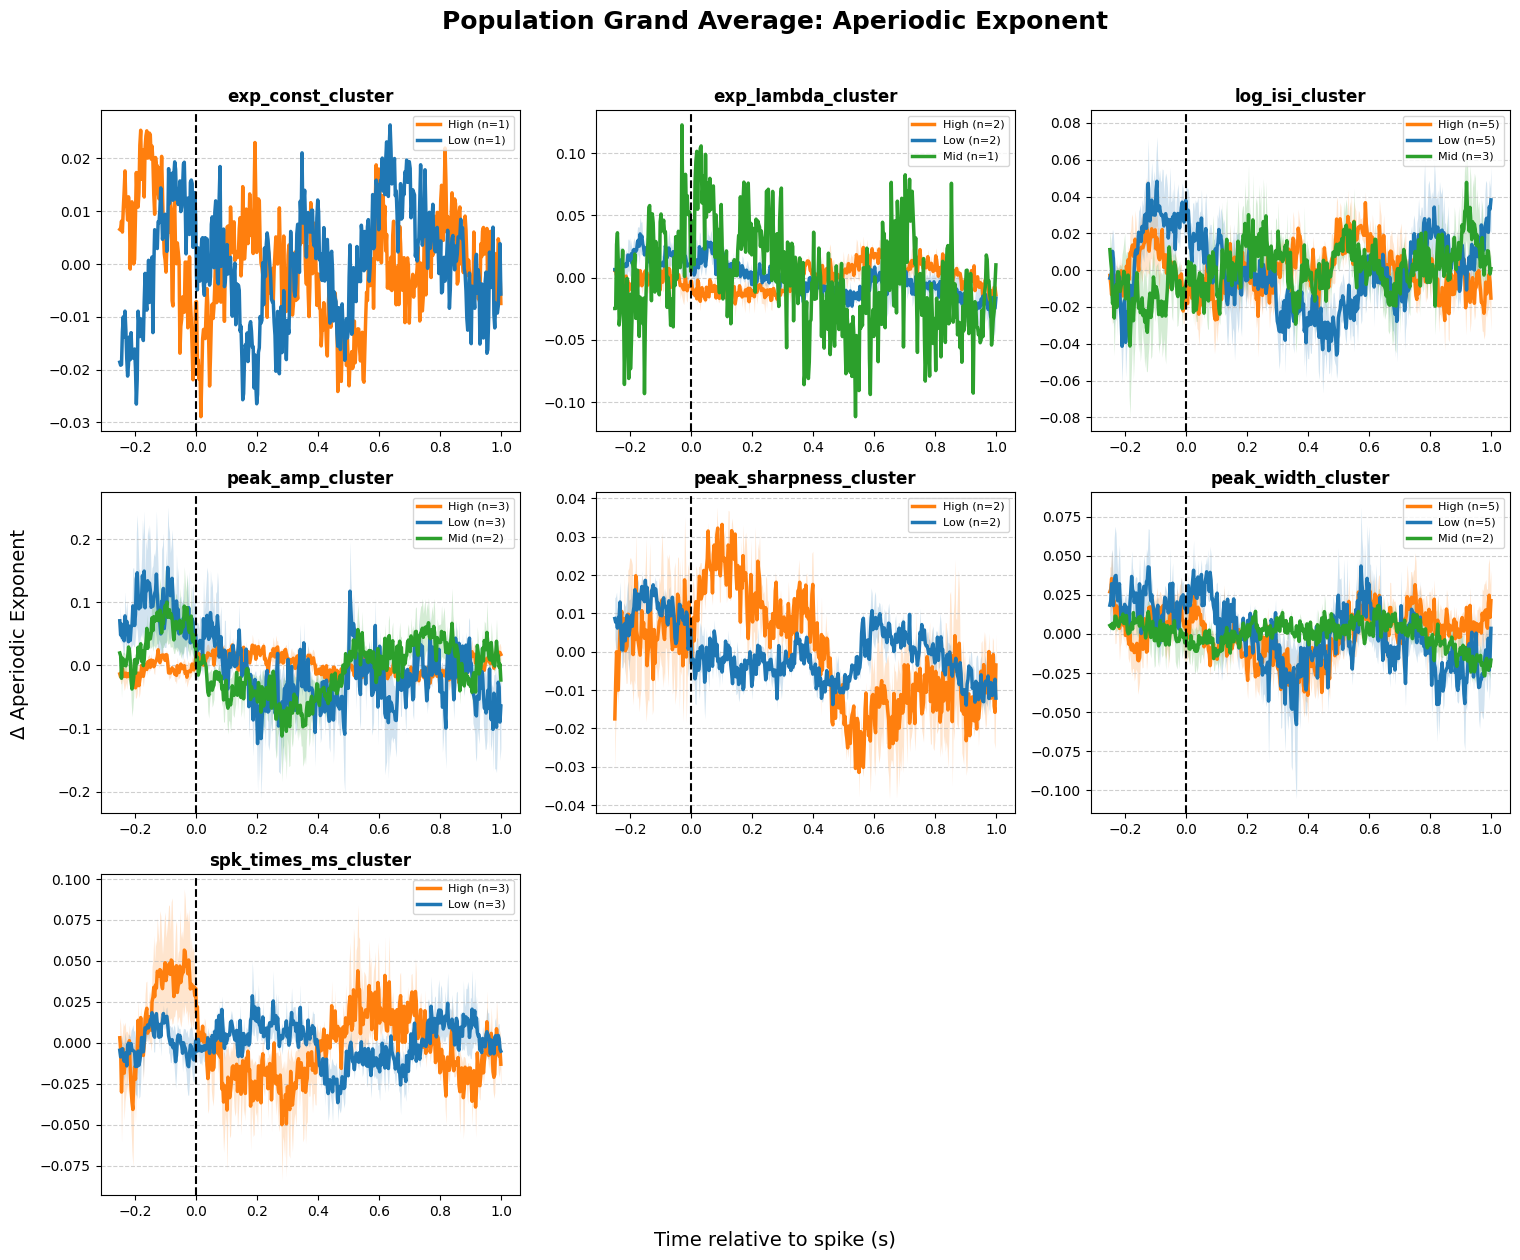

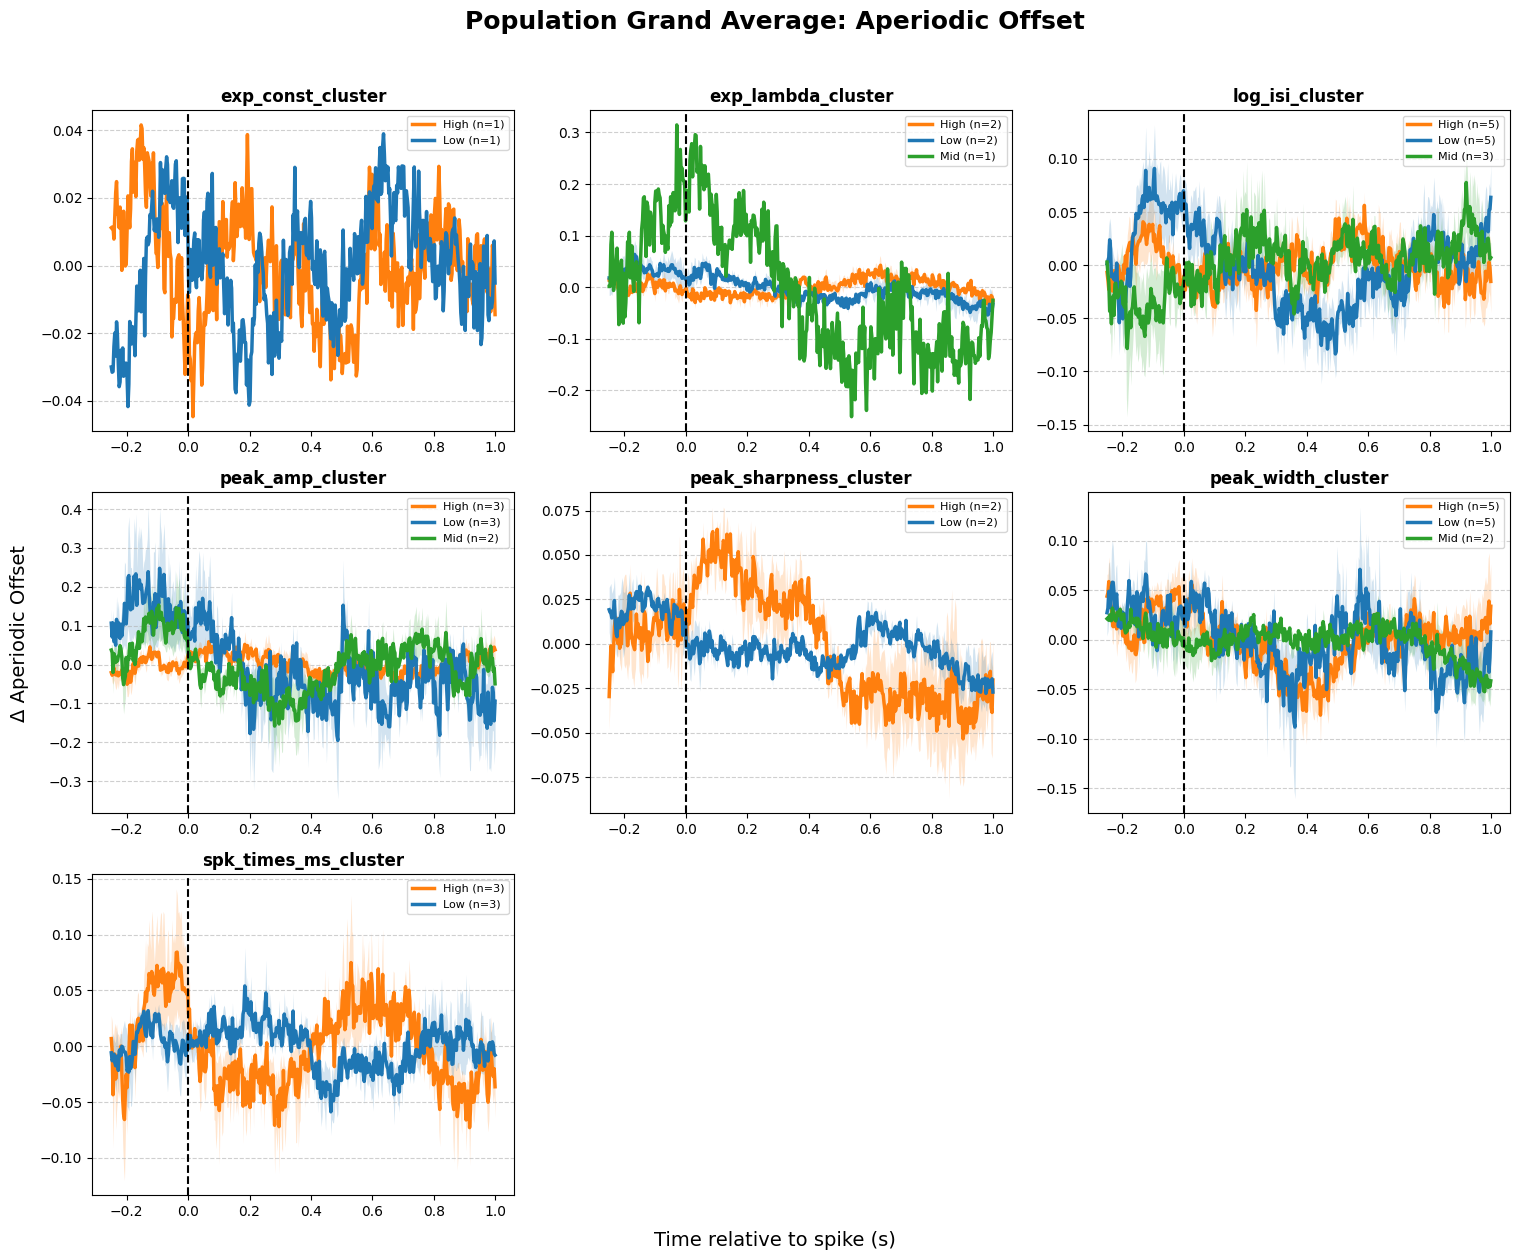

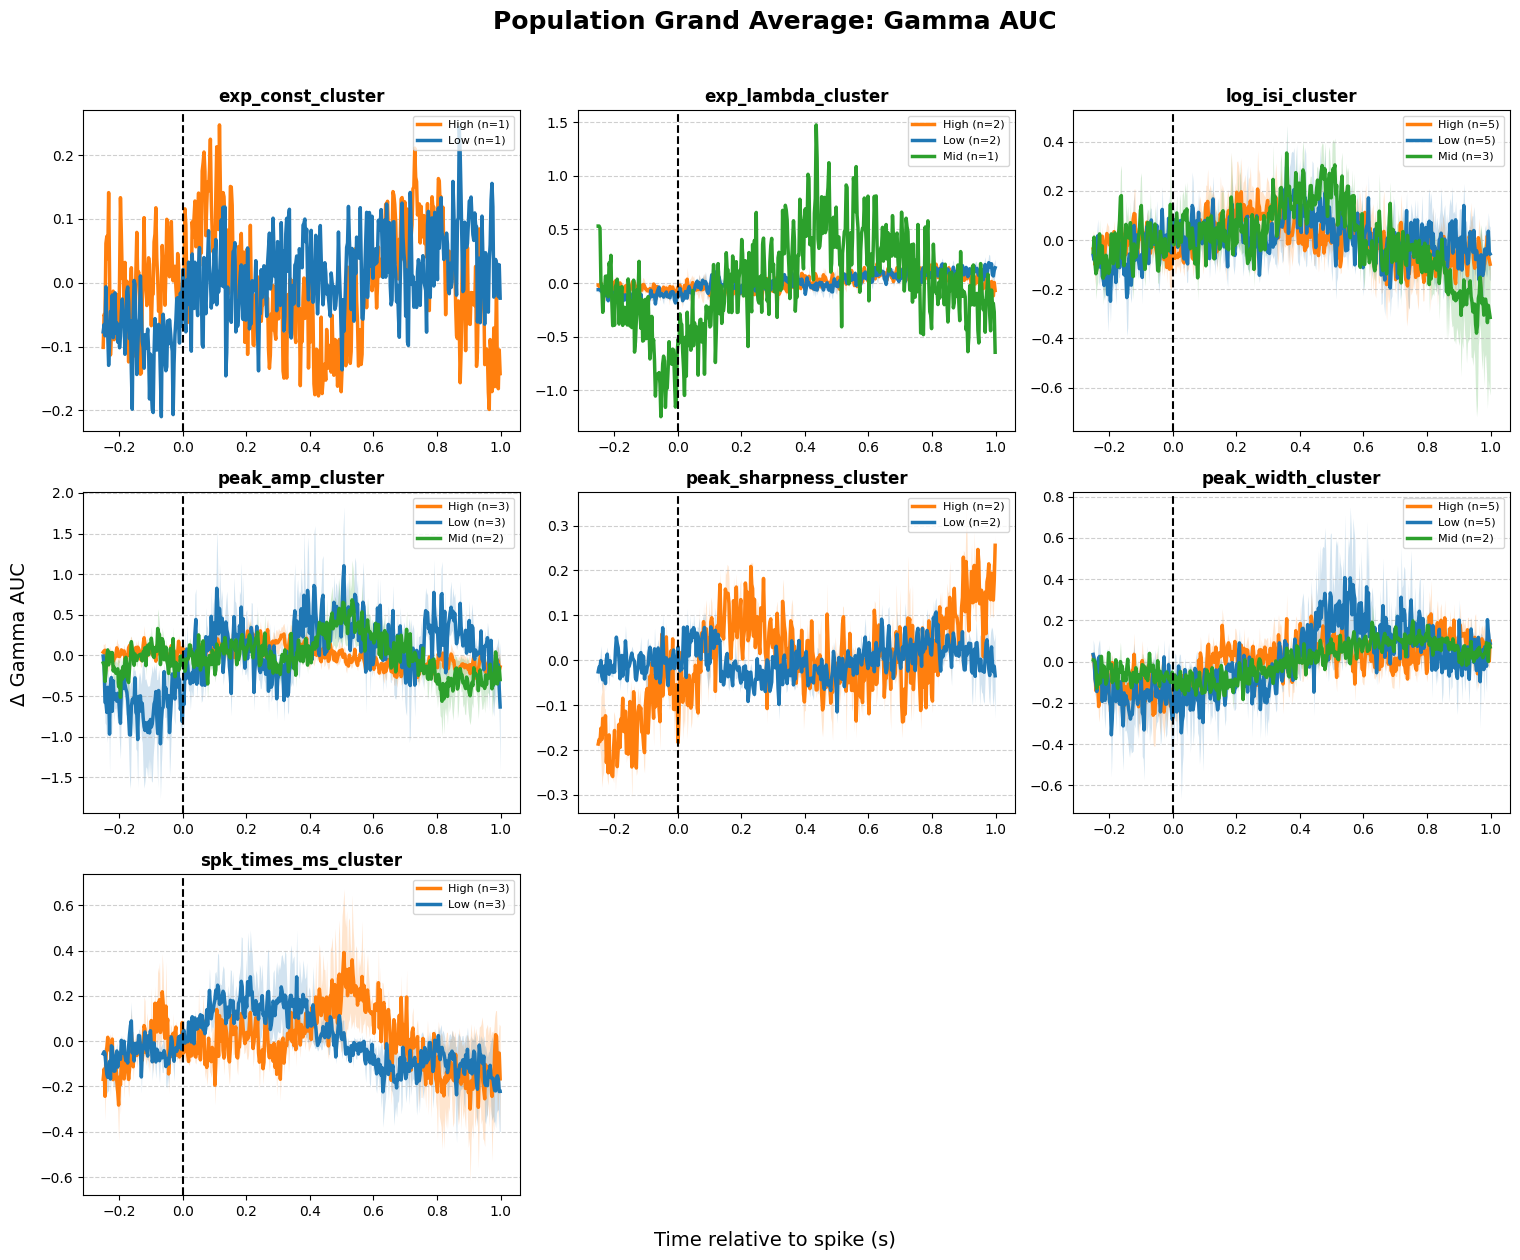

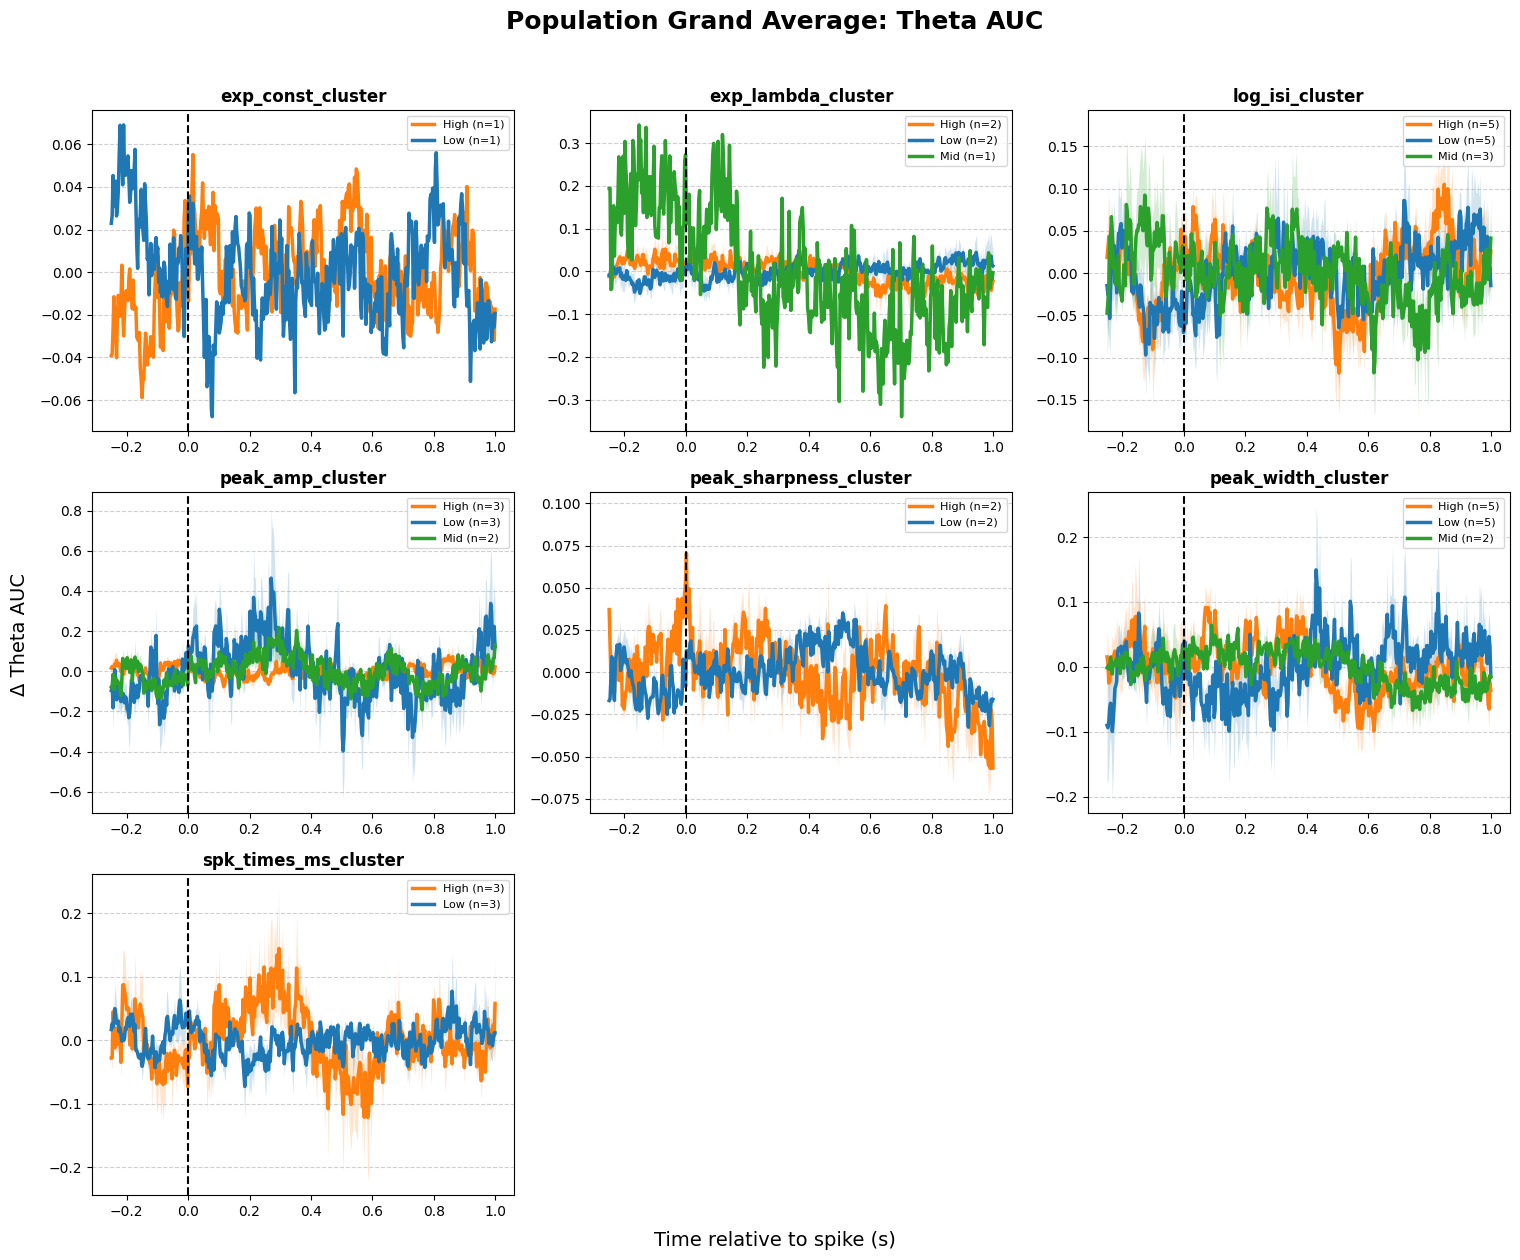

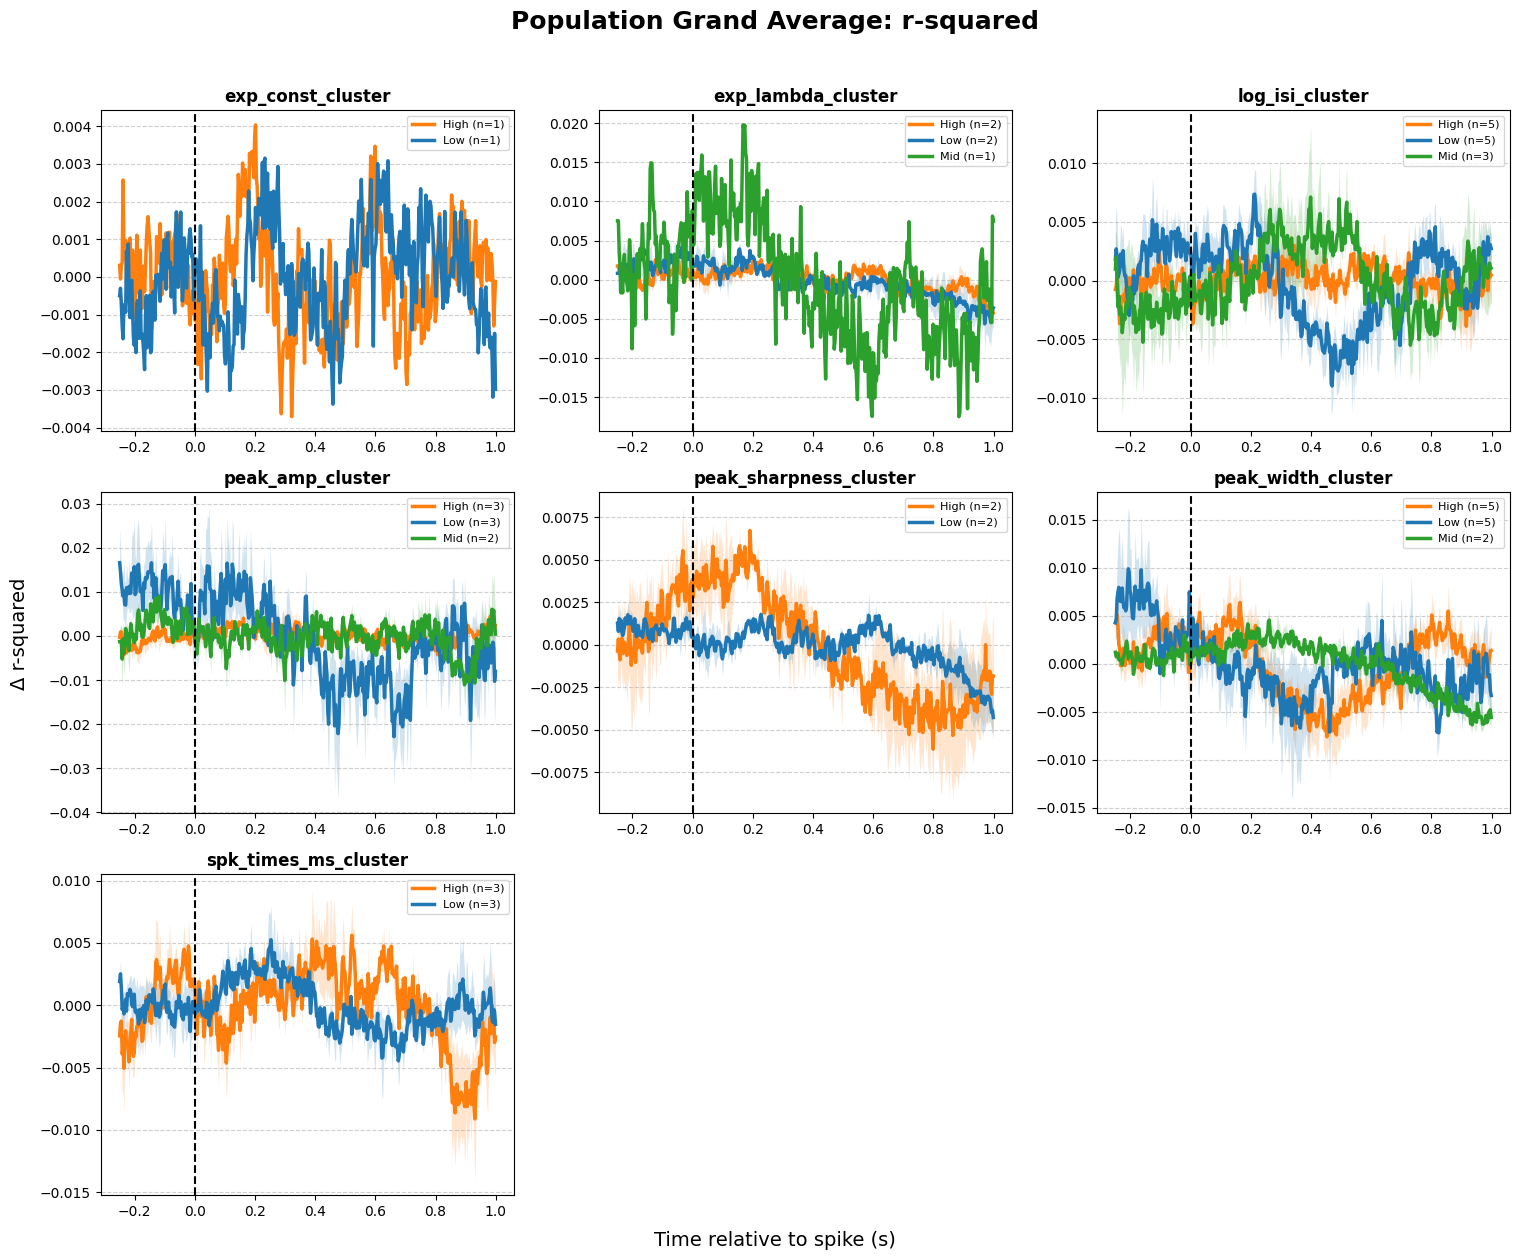

In [18]:
plot_all_grand_average_traces(pop_traces)